# DS-3002 Assignment 4

In [63]:
# Global imports and settings
import warnings
warnings.filterwarnings("ignore")

import os
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    silhouette_score, adjusted_rand_score, roc_curve
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.ensemble import RandomForestClassifier

# Ensure SMOTE dependency is available in the active notebook kernel
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

import sys
import subprocess

try:
    import shap
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

import joblib

import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

## Preprocessing and Data Setup

### Pre-1 Load data, verify shape, head, and dtypes

In [64]:
# Pre-1: load Cleveland data
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal", "target"
]

data_path = "processed.cleveland.data"
heart_raw = pd.read_csv(data_path, header=None, names=columns)

print("Raw shape:", heart_raw.shape)
display(heart_raw.head())
display(heart_raw.dtypes.to_frame("dtype").T)

Raw shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str,str,int64


### Pre-2 Missing values handling (`?` to `NaN`) and row retention

In [65]:
# Pre-2: convert ? to NaN and clean
heart = heart_raw.replace("?", np.nan).copy()

for c in heart.columns:
    heart[c] = pd.to_numeric(heart[c], errors="coerce")

missing_counts = heart.isna().sum()
missing_cols = missing_counts[missing_counts > 0]
print("Columns with missing values and counts:")
display(missing_cols.to_frame("missing_rows"))

before_rows = len(heart)
heart = heart.dropna().reset_index(drop=True)

# UCI Cleveland target is 0-4 (ordinal); assignment uses binary: 0=no disease, 1=present
heart["target"] = (heart["target"] > 0).astype(int)

# Map raw Cleveland codes to assignment ranges
# cp: raw 1-4 -> assignment 0-3
heart["cp"] = heart["cp"] - 1
# slope: raw 1-3 -> assignment 0-2
heart["slope"] = heart["slope"] - 1
# thal: raw {3,6,7} -> assignment {1,2,3}
heart["thal"] = heart["thal"].map({3: 1, 6: 2, 7: 3})

# Safety: drop any rows made invalid by mapping
heart = heart.dropna().reset_index(drop=True)
heart["cp"] = heart["cp"].astype(int)
heart["slope"] = heart["slope"].astype(int)
heart["thal"] = heart["thal"].astype(int)

after_rows = len(heart)

print(f"Rows before drop: {before_rows}")
print(f"Rows after drop:  {after_rows}")
print("Value ranges after mapping:")
print("cp:", (heart["cp"].min(), heart["cp"].max()))
print("slope:", (heart["slope"].min(), heart["slope"].max()))
print("thal:", (heart["thal"].min(), heart["thal"].max()))


Columns with missing values and counts:


,missing_rows
ca,4
thal,2


Rows before drop: 303
Rows after drop:  297


### Pre-3 Target distribution and imbalance strategy (SMOTE on training only)

**Note:** After Pre-2, `target` is binary: Cleveland’s original `0`–`4` labels are collapsed to `0` (no disease) and `1` (disease present), matching the assignment spec.

In [66]:
# Pre-3: class distribution
class_counts = heart["target"].value_counts().sort_index()
class_pct = heart["target"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({"count": class_counts, "percent": class_pct.round(2)})
display(summary)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
print("Strategy: apply SMOTE only on training data for model training where needed.")

,count,percent
target,,
0,160,53.87
1,137,46.13


Imbalance ratio (majority/minority): 1.17
Strategy: apply SMOTE only on training data for model training where needed.


### Pre-4 and Pre-5 Encoding, scaling, and stratified 80/20 split (`random_state=42`)

In [67]:
# Pre-4/5: split and preprocessing pipeline
categorical_cols = ["cp", "restecg", "slope", "thal"]
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
binary_cols = ["sex", "fbs", "exang"]

X = heart.drop(columns=["target"])
y = heart["target"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("cont", StandardScaler(), continuous_cols),
        ("bin", "passthrough", binary_cols),
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Train shape:", X_train.shape, "Processed:", X_train_proc.shape)
print("Test shape:", X_test.shape, "Processed:", X_test_proc.shape)

Train shape: (237, 13) Processed: (237, 22)
Test shape: (60, 13) Processed: (60, 22)


### Pre-6 Correlation heatmap and strongest correlated feature pairs

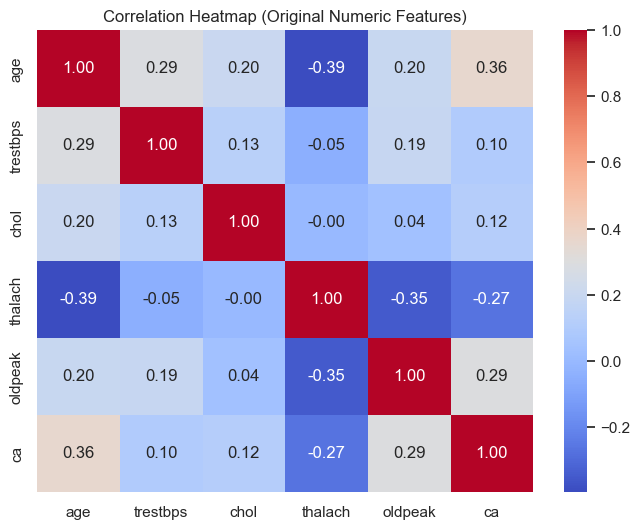

Top 3 strongest absolute correlations:
age vs thalach: -0.395
age vs ca: 0.362
thalach vs oldpeak: -0.348
Naive Bayes note: stronger feature dependence can violate independence assumption.


In [68]:
# Pre-6: correlation analysis on original numeric features
numeric_for_corr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
corr = heart[numeric_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Original Numeric Features)")
plt.show()

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top3_corr = corr_pairs.abs().sort_values(ascending=False).head(3)
print("Top 3 strongest absolute correlations:")
for (f1, f2), v in top3_corr.items():
    print(f"{f1} vs {f2}: {corr.loc[f1, f2]:.3f}")

print("Naive Bayes note: stronger feature dependence can violate independence assumption.")

In [69]:
# Utility: unified metric function

def evaluate_binary_model(model_name, y_true, y_pred, y_proba):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = np.asarray(y_pred).astype(int).ravel()
    # Cleveland raw labels can be 0-4; ensure binary {0,1} for sklearn metrics
    if np.unique(y_true).size > 2 or np.unique(y_pred).size > 2:
        y_true = (y_true > 0).astype(int)
        y_pred = (y_pred > 0).astype(int)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "disease_recall": recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_proba),
    }

## Part A: Unsupervised Learning

### A1 K-Means (WCSS, Silhouette, PCA views, cluster profiling, ARI vs labels)

Chosen k (highest silhouette): 2


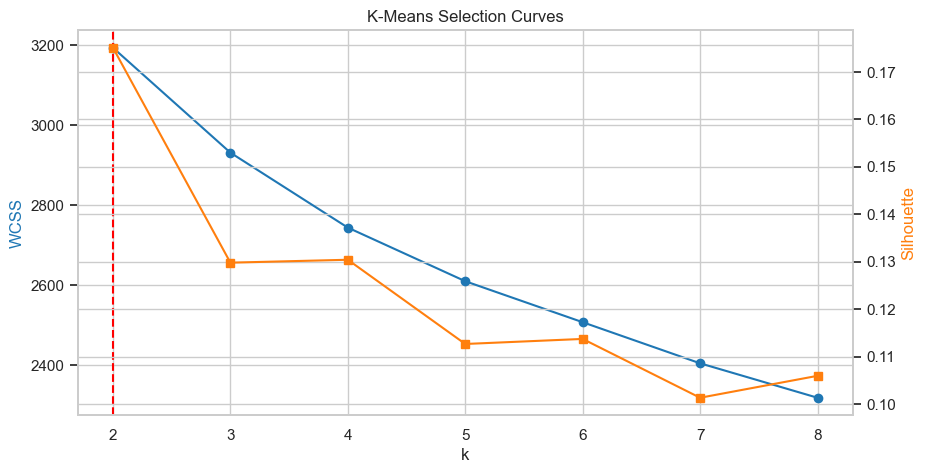

In [70]:
# A1: prepare unsupervised matrix (standardized without target)
unsup_features = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]
X_unsup = heart[unsup_features].copy()
X_unsup_std = StandardScaler().fit_transform(X_unsup)

k_values = list(range(2, 9))
inertias, silhouettes = [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_unsup_std)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_unsup_std, labels_k))

chosen_k = k_values[int(np.argmax(silhouettes))]
print("Chosen k (highest silhouette):", chosen_k)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(k_values, inertias, marker="o", color="tab:blue", label="WCSS")
ax2.plot(k_values, silhouettes, marker="s", color="tab:orange", label="Silhouette")
ax1.axvline(chosen_k, linestyle="--", color="red")
ax1.set_xlabel("k")
ax1.set_ylabel("WCSS", color="tab:blue")
ax2.set_ylabel("Silhouette", color="tab:orange")
plt.title("K-Means Selection Curves")
plt.show()

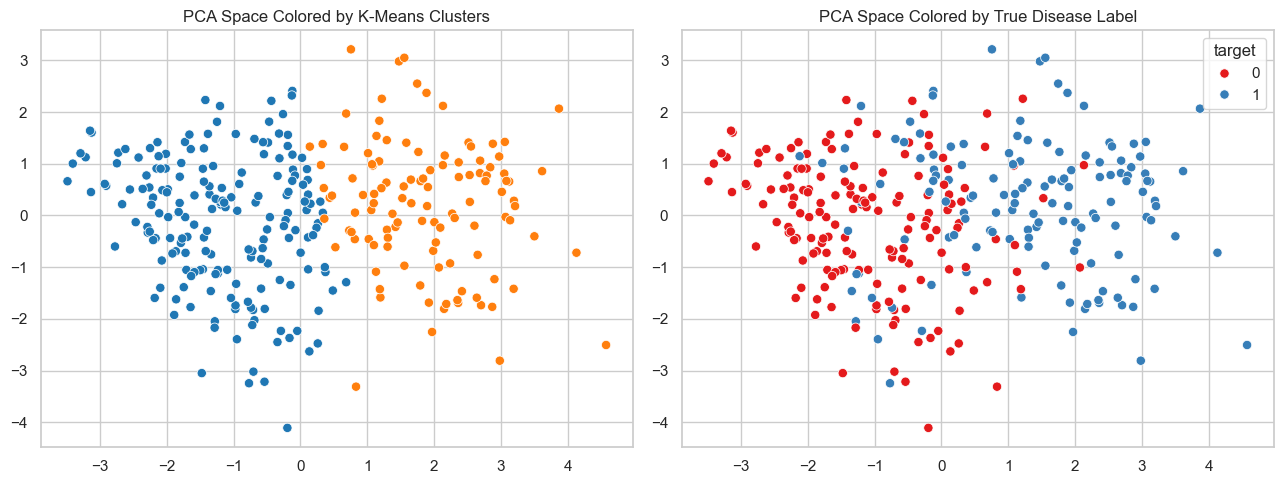

,cluster,cluster_size,disease_ratio,mean_thalach,mean_oldpeak,mean_cp
0,0,184,20.11,159.880435,0.542935,2.782609
1,1,113,88.50,132.858407,1.890265,3.769912


ARI (K-Means vs true labels): 0.4380


In [71]:
# A1: PCA scatter by cluster vs true label
kmeans_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_unsup_std)

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_unsup_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=cluster_labels, palette="tab10", s=45, ax=axes[0], legend=False)
axes[0].set_title("PCA Space Colored by K-Means Clusters")

sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=heart["target"], palette="Set1", s=45, ax=axes[1])
axes[1].set_title("PCA Space Colored by True Disease Label")
plt.tight_layout()
plt.show()

cluster_df = heart.copy()
cluster_df["cluster"] = cluster_labels
profile = cluster_df.groupby("cluster").agg(
    cluster_size=("target", "size"),
    disease_ratio=("target", "mean"),
    mean_thalach=("thalach", "mean"),
    mean_oldpeak=("oldpeak", "mean"),
    mean_cp=("cp", "mean")
).reset_index()
profile["disease_ratio"] = (profile["disease_ratio"] * 100).round(2)

display(profile)

ari_kmeans_vs_true = adjusted_rand_score(heart["target"], cluster_labels)
print(f"ARI (K-Means vs true labels): {ari_kmeans_vs_true:.4f}")

### A2 Hierarchical clustering (Ward linkage, dendrogram, crosstab, ARI vs K-Means)

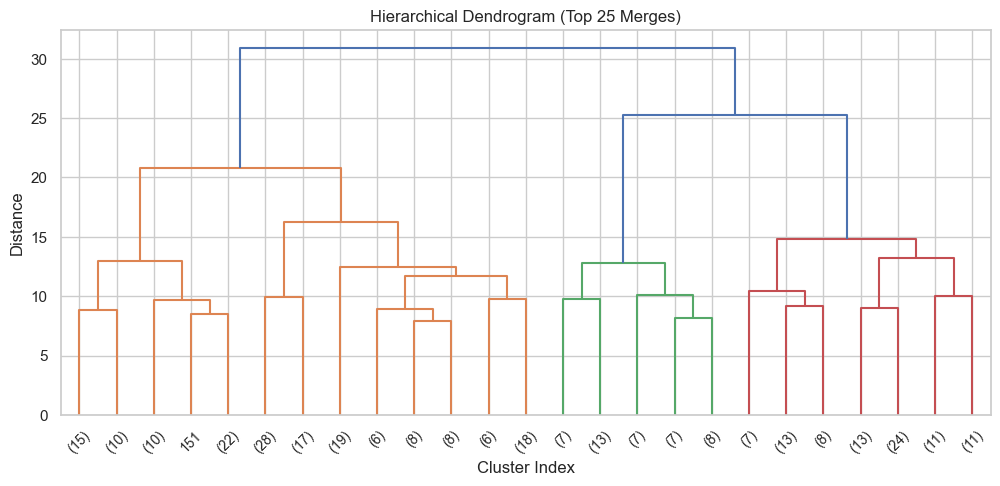

target,0,1,All
hier_cluster,,,
0,117,51,168
1,43,86,129
All,160,137,297


ARI (Hierarchical vs K-Means): 0.3688


In [72]:
# A2: Ward linkage and cluster cutting
Z = linkage(X_unsup_std, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Dendrogram (Top 25 Merges)")
plt.xlabel("Cluster Index")
plt.ylabel("Distance")
plt.show()

h_k = chosen_k
h_labels = fcluster(Z, t=h_k, criterion="maxclust") - 1

crosstab_h = pd.crosstab(pd.Series(h_labels, name="hier_cluster"), heart["target"], margins=True)
display(crosstab_h)

ari_h_vs_km = adjusted_rand_score(h_labels, cluster_labels)
print(f"ARI (Hierarchical vs K-Means): {ari_h_vs_km:.4f}")

### A3 PCA explained variance and t-SNE separability

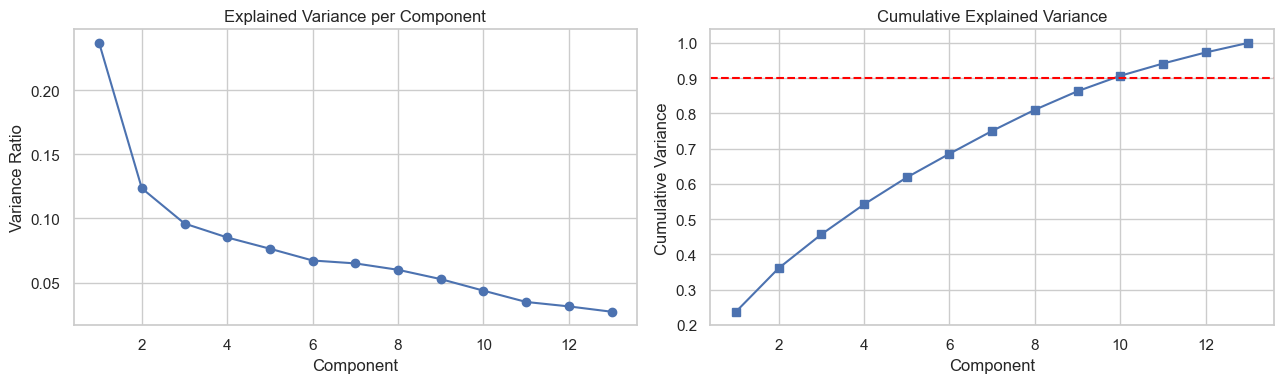

Components needed for 90% variance: 10


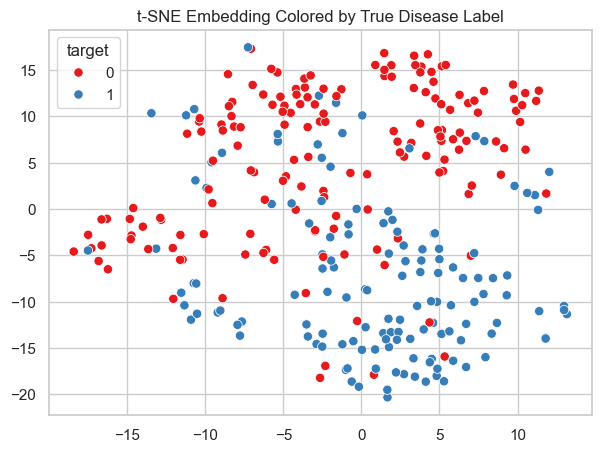

In [73]:
# A3: PCA variance and t-SNE plot
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_unsup_std)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
components_90 = int(np.argmax(cum_var >= 0.90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, len(exp_var) + 1), exp_var, marker="o")
axes[0].set_title("Explained Variance per Component")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance Ratio")

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker="s")
axes[1].axhline(0.90, linestyle="--", color="red")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Cumulative Variance")
plt.tight_layout()
plt.show()

print(f"Components needed for 90% variance: {components_90}")

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_unsup_std)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=heart["target"], palette="Set1", s=45)
plt.title("t-SNE Embedding Colored by True Disease Label")
plt.show()

## Part B: Bagging and Boosting

### B1 Random Forest (CV tuning, OOB curve, importances, evaluation)

In [74]:
# B1: Random Forest tuning with SMOTE on train only
rf_pipe = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE, oob_score=True, bootstrap=True))
])

rf_param_grid = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [None, 5, 10]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, scoring="f1_macro", cv=cv5, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV macro F1:", round(rf_grid.best_score_, 4))
rf_best = rf_grid.best_estimator_

Best RF params: {'rf__max_depth': 5, 'rf__n_estimators': 50}
Best RF CV macro F1: 0.81


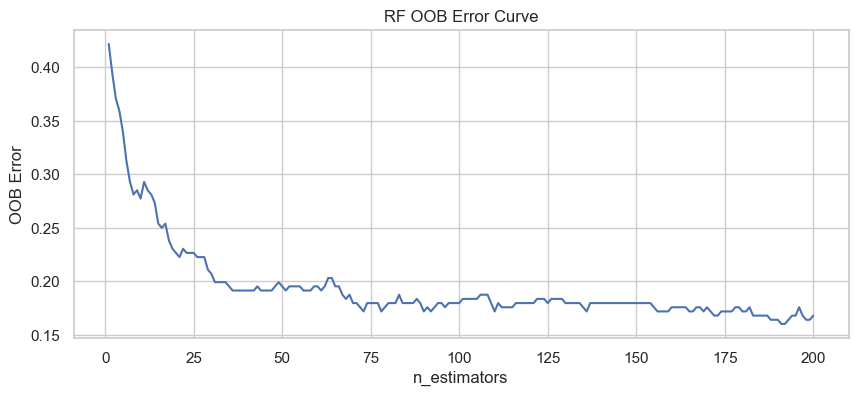

In [75]:
# B1: OOB error vs number of trees
oob_errors = []
for n in range(1, 201):
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        max_depth=rf_grid.best_params_["rf__max_depth"],
        oob_score=True,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    pipe_tmp = ImbPipeline(steps=[("prep", preprocessor), ("smote", SMOTE(random_state=RANDOM_STATE)), ("rf", rf_tmp)])
    pipe_tmp.fit(X_train, y_train)
    oob_errors.append(1 - pipe_tmp.named_steps["rf"].oob_score_)

plt.figure(figsize=(10, 4))
plt.plot(range(1, 201), oob_errors)
plt.xlabel("n_estimators")
plt.ylabel("OOB Error")
plt.title("RF OOB Error Curve")
plt.show()

model              Random Forest
accuracy                0.833333
macro_precision         0.834842
macro_recall            0.830357
macro_f1                 0.83165
disease_recall          0.785714
auc_roc                 0.922991
dtype: object


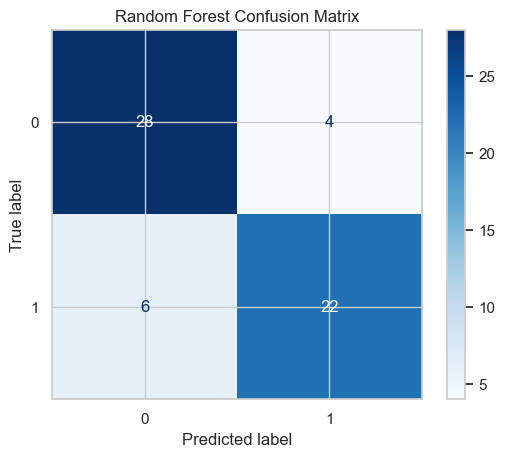

,feature,importance
3,cat__cp_4.0,0.120068
10,cat__thal_3.0,0.113477
18,cont__ca,0.100793
12,cat__thal_7.0,0.100050
17,cont__oldpeak,0.077347


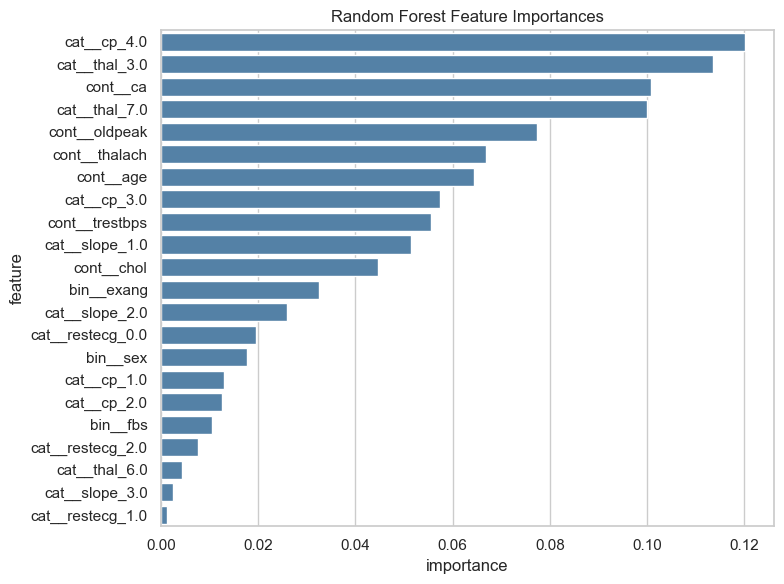

In [76]:
# B1: feature importances and metrics
rf_best.fit(X_train, y_train)
rf_pred = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]

rf_metrics = evaluate_binary_model("Random Forest", y_test, rf_pred, rf_proba)
print(pd.Series(rf_metrics))

cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

rf_model_inner = rf_best.named_steps["rf"]
rf_feature_names = rf_best.named_steps["prep"].get_feature_names_out()
fi = pd.DataFrame({"feature": rf_feature_names, "importance": rf_model_inner.feature_importances_}).sort_values("importance", ascending=False)

display(fi.head(5))

plt.figure(figsize=(8, 6))
sns.barplot(data=fi, x="importance", y="feature", color="steelblue")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

### B2 Gradient Boosting (XGBoost preferred, CV tuning, early stopping, SHAP, evaluation)

In [77]:
# B2: choose boosting model
boosting_name = None
try:
    from xgboost import XGBClassifier
    boosting_name = "XGBoost"
except Exception:
    from lightgbm import LGBMClassifier
    boosting_name = "LightGBM"

print("Boosting model selected:", boosting_name)

Boosting model selected: XGBoost


In [78]:
# B2: CV tuning
if boosting_name == "XGBoost":
    boost_model = XGBClassifier(
        objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_STATE,
        n_estimators=500, subsample=1.0, colsample_bytree=1.0
    )
    param_grid = {"boost__learning_rate": [0.01, 0.1, 0.3], "boost__max_depth": [3, 5, 7]}
else:
    boost_model = LGBMClassifier(objective="binary", random_state=RANDOM_STATE, n_estimators=500)
    param_grid = {"boost__learning_rate": [0.01, 0.1, 0.3], "boost__max_depth": [3, 5, 7]}

boost_pipe = ImbPipeline(steps=[("prep", preprocessor), ("smote", SMOTE(random_state=RANDOM_STATE)), ("boost", boost_model)])
boost_grid = GridSearchCV(boost_pipe, param_grid, scoring="f1_macro", cv=cv5, n_jobs=-1)
boost_grid.fit(X_train, y_train)

print("Best boosting params:", boost_grid.best_params_)
print("Best boosting CV macro F1:", round(boost_grid.best_score_, 4))

Best boosting params: {'boost__learning_rate': 0.01, 'boost__max_depth': 3}
Best boosting CV macro F1: 0.7935


model               XGBoost
accuracy           0.866667
macro_precision    0.868778
macro_recall       0.863839
macro_f1            0.86532
disease_recall     0.821429
auc_roc            0.904018
dtype: object


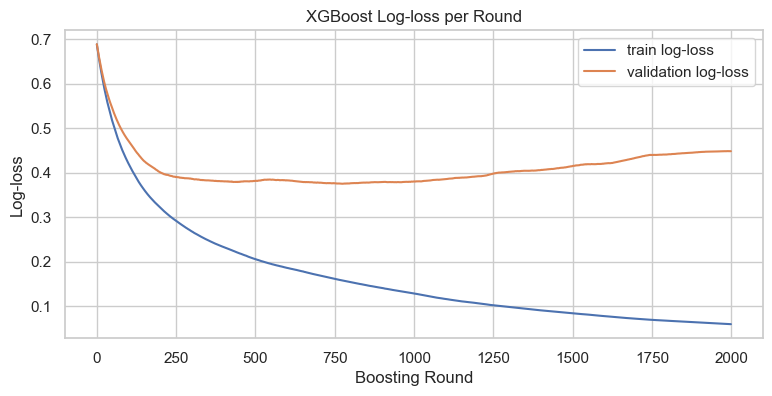

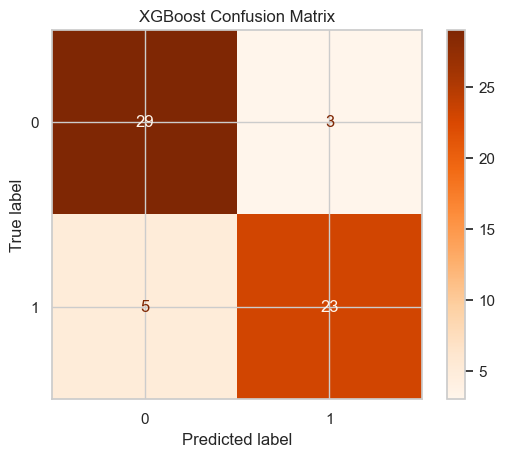

In [79]:
# B2: final training with early stopping and loss curves
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

sm = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = sm.fit_resample(X_train_enc, y_train)

if boosting_name == "XGBoost":
    final_boost = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_estimators=2000,
        learning_rate=boost_grid.best_params_["boost__learning_rate"],
        max_depth=boost_grid.best_params_["boost__max_depth"],
    )
    final_boost.fit(
        X_train_bal, y_train_bal,
        eval_set=[(X_train_bal, y_train_bal), (X_test_enc, y_test)],
        verbose=False,
    )
    evals = final_boost.evals_result()
    train_loss = evals["validation_0"]["logloss"]
    val_loss = evals["validation_1"]["logloss"]
else:
    final_boost = LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_estimators=2000,
        learning_rate=boost_grid.best_params_["boost__learning_rate"],
        max_depth=boost_grid.best_params_["boost__max_depth"],
    )
    final_boost.fit(X_train_bal, y_train_bal)
    train_loss = []
    val_loss = []

boost_pred = final_boost.predict(X_test_enc)
boost_proba = final_boost.predict_proba(X_test_enc)[:, 1]
boost_metrics = evaluate_binary_model(boosting_name, y_test, boost_pred, boost_proba)
print(pd.Series(boost_metrics))

if len(train_loss) > 0:
    plt.figure(figsize=(9, 4))
    plt.plot(train_loss, label="train log-loss")
    plt.plot(val_loss, label="validation log-loss")
    plt.xlabel("Boosting Round")
    plt.ylabel("Log-loss")
    plt.legend()
    plt.title(f"{boosting_name} Log-loss per Round")
    plt.show()

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, boost_pred)).plot(cmap="Oranges")
plt.title(f"{boosting_name} Confusion Matrix")
plt.show()

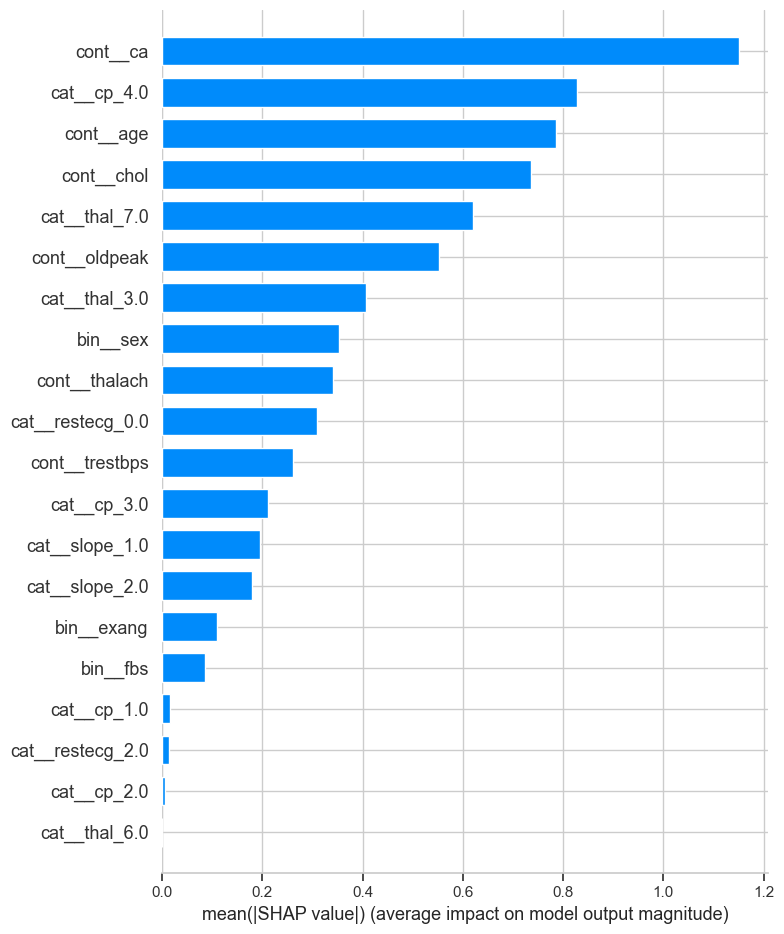

In [80]:
# B2: SHAP analysis (test set)
explainer = shap.TreeExplainer(final_boost)
shap_values = explainer.shap_values(X_test_enc)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_test_enc, feature_names=feature_names, plot_type="bar")

### B3 Ensemble comparison table and combined ROC curves

,model,accuracy,macro_precision,macro_recall,macro_f1,disease_recall,auc_roc,train_time_sec
0,Logistic Regression,0.866667,0.866071,0.866071,0.866071,0.857143,0.945312,0.048344
1,Random Forest,0.833333,0.834842,0.830357,0.831650,0.785714,0.922991,NaN
2,XGBoost,0.866667,0.868778,0.863839,0.865320,0.821429,0.904018,NaN


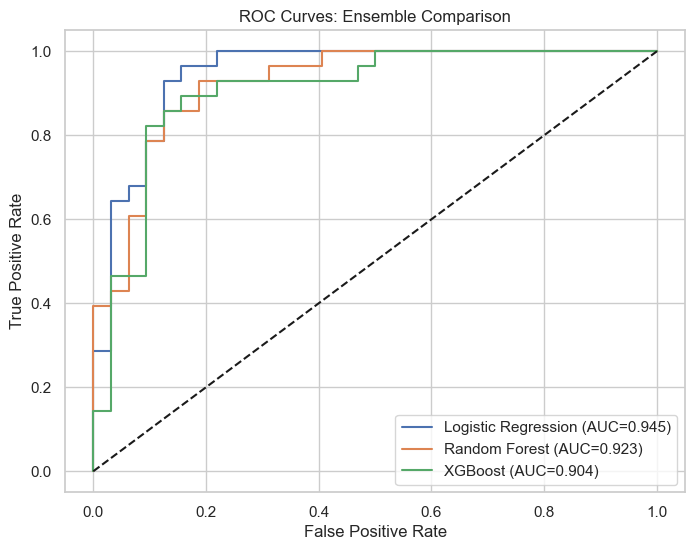

In [81]:
# B3: add a third baseline classifier and compare
from sklearn.linear_model import LogisticRegression

lr_pipe = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("lr", LogisticRegression(max_iter=500, random_state=RANDOM_STATE))
])
start = time.time()
lr_pipe.fit(X_train, y_train)
lr_time = time.time() - start

lr_pred = lr_pipe.predict(X_test)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_metrics = evaluate_binary_model("Logistic Regression", y_test, lr_pred, lr_proba)
lr_metrics["train_time_sec"] = lr_time

rf_metrics["train_time_sec"] = np.nan
boost_metrics["train_time_sec"] = np.nan
comparison_df = pd.DataFrame([lr_metrics, rf_metrics, boost_metrics])
display(comparison_df)

plt.figure(figsize=(8, 6))
for name, prob in [
    ("Logistic Regression", lr_proba),
    ("Random Forest", rf_proba),
    (boosting_name, boost_proba),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Ensemble Comparison")
plt.legend()
plt.show()

## Part C: ANN on Tabular Data

### C1 Single-Layer Perceptron (SLP)

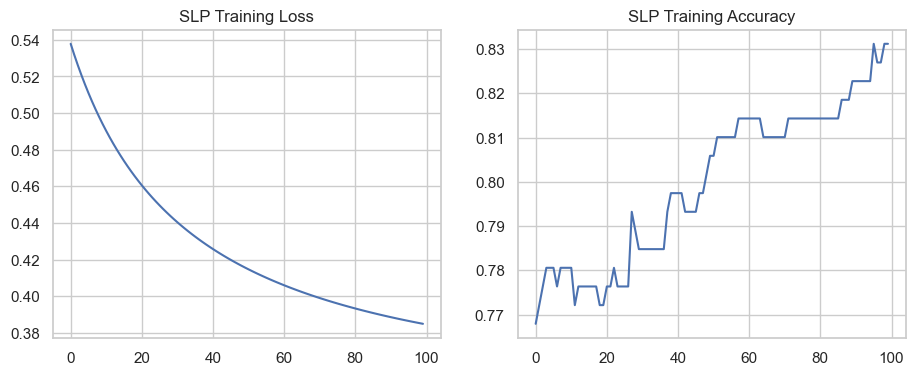

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
accuracy    0.866667
f1          0.857143
auc         0.931920
dtype: float64


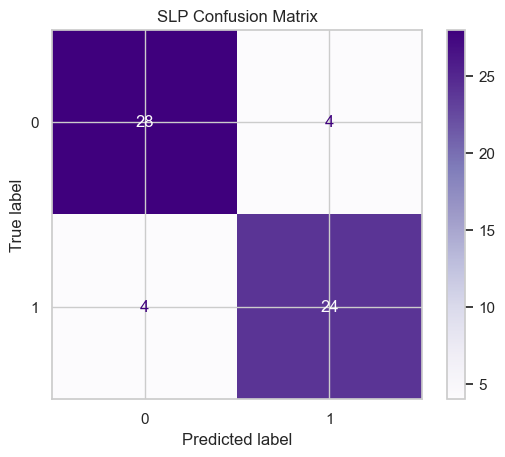

,feature,abs_weight
10,cat__thal_3.0,0.777761
12,cat__thal_7.0,0.755852
3,cat__cp_4.0,0.704194


In [82]:
# C1: SLP model
X_train_nn = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc
X_test_nn = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

y_train_np = y_train.values
y_test_np = y_test.values

slp = Sequential([
    Input(shape=(X_train_nn.shape[1],)),
    Dense(1, activation="sigmoid")
])
slp.compile(optimizer=SGD(learning_rate=0.01), loss="binary_crossentropy", metrics=["accuracy"])

slp_hist = slp.fit(X_train_nn, y_train_np, epochs=100, batch_size=32, verbose=0)

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(slp_hist.history["loss"])
plt.title("SLP Training Loss")
plt.subplot(1, 2, 2)
plt.plot(slp_hist.history["accuracy"])
plt.title("SLP Training Accuracy")
plt.show()

slp_pred_proba = slp.predict(X_test_nn).ravel()
slp_pred = (slp_pred_proba >= 0.5).astype(int)

slp_metrics = {
    "accuracy": accuracy_score(y_test_np, slp_pred),
    "f1": f1_score(y_test_np, slp_pred),
    "auc": roc_auc_score(y_test_np, slp_pred_proba),
}
print(pd.Series(slp_metrics))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_np, slp_pred)).plot(cmap="Purples")
plt.title("SLP Confusion Matrix")
plt.show()

slp_weights = np.abs(slp.get_weights()[0].ravel())
weight_df = pd.DataFrame({"feature": feature_names, "abs_weight": slp_weights}).sort_values("abs_weight", ascending=False)
display(weight_df.head(3))

### C2 Multi-Layer Perceptron (3 architectures, final model, CV, evaluation)

In [83]:
# C2: architecture experiments
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_nn, y_train_np, test_size=0.2, stratify=y_train_np, random_state=RANDOM_STATE
)

def build_mlp(layers, activation="relu", dropout=0.3, l2_reg=0.0):
    model = Sequential([Input(shape=(X_train_nn.shape[1],))])
    for units in layers:
        model.add(Dense(units, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return model

architectures = {
    "Small": [32],
    "Medium": [64, 32],
    "Large": [128, 64, 32],
}

arch_results = []
for name, layers in architectures.items():
    model_tmp = build_mlp(layers, activation="relu", dropout=0.3, l2_reg=1e-4)
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    t0 = time.time()
    hist = model_tmp.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=150, batch_size=32, verbose=0, callbacks=[es])
    train_time = time.time() - t0
    val_pred = (model_tmp.predict(X_val).ravel() >= 0.5).astype(int)
    val_f1 = f1_score(y_val, val_pred)
    arch_results.append({"architecture": name, "val_f1": val_f1, "train_time_sec": round(train_time, 2), "notes": f"layers={layers}"})

arch_df = pd.DataFrame(arch_results).sort_values("val_f1", ascending=False)
display(arch_df)
best_arch_name = arch_df.iloc[0]["architecture"]
best_layers = architectures[best_arch_name]
print("Selected architecture:", best_arch_name, best_layers)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


,architecture,val_f1,train_time_sec,notes
0,Small,0.851064,6.90,layers=[32]
1,Medium,0.826087,6.64,"layers=[64, 32]"
2,Large,0.826087,4.36,"layers=[128, 64, 32]"


Selected architecture: Small [32]


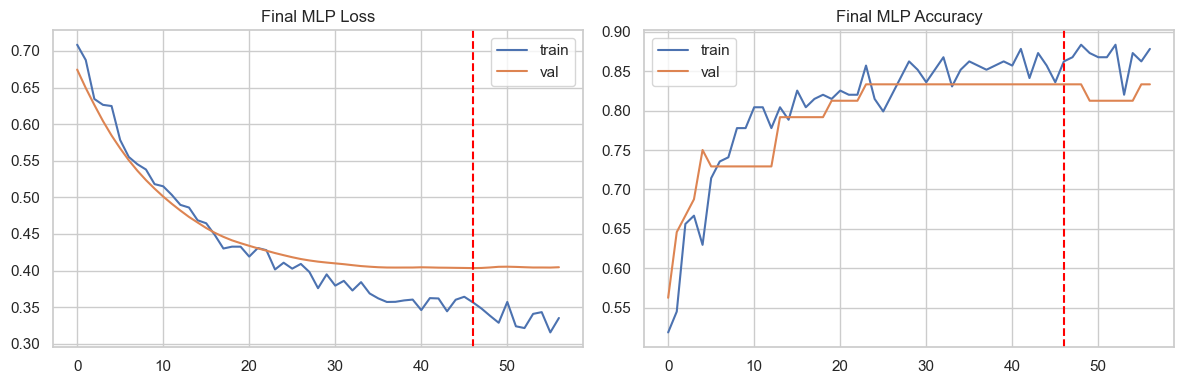

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
model              Final MLP
accuracy            0.883333
macro_precision     0.883838
macro_recall        0.881696
macro_f1            0.882517
disease_recall      0.857143
auc_roc             0.953125
dtype: object


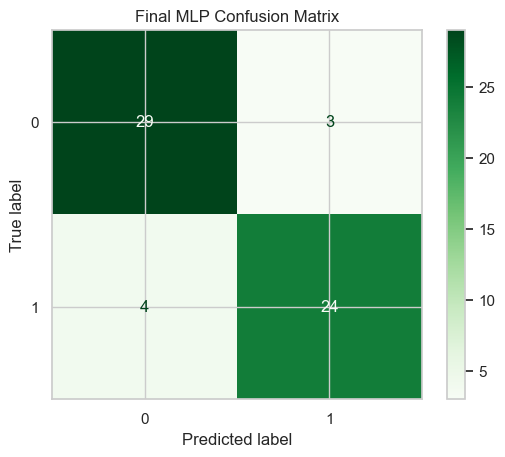

In [84]:
# C2: final MLP training and plots
final_mlp = build_mlp(best_layers, activation="relu", dropout=0.3, l2_reg=1e-4)
es_final = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

hist_final = final_mlp.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[es_final],
    verbose=0,
)

best_epoch = int(np.argmin(hist_final.history["val_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_final.history["loss"], label="train")
axes[0].plot(hist_final.history["val_loss"], label="val")
axes[0].axvline(best_epoch - 1, linestyle="--", color="red")
axes[0].set_title("Final MLP Loss")
axes[0].legend()

axes[1].plot(hist_final.history["accuracy"], label="train")
axes[1].plot(hist_final.history["val_accuracy"], label="val")
axes[1].axvline(best_epoch - 1, linestyle="--", color="red")
axes[1].set_title("Final MLP Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

mlp_proba = final_mlp.predict(X_test_nn).ravel()
mlp_pred = (mlp_proba >= 0.5).astype(int)

mlp_metrics = evaluate_binary_model("Final MLP", y_test_np, mlp_pred, mlp_proba)
print(pd.Series(mlp_metrics))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test_np, mlp_pred)).plot(cmap="Greens")
plt.title("Final MLP Confusion Matrix")
plt.show()

In [85]:
# C2: 5-fold CV summary for MLP (manual loop)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc, cv_f1 = [], []

for tr_idx, va_idx in skf.split(X_train_nn, y_train_np):
    X_tr_fold, X_va_fold = X_train_nn[tr_idx], X_train_nn[va_idx]
    y_tr_fold, y_va_fold = y_train_np[tr_idx], y_train_np[va_idx]

    m = build_mlp(best_layers, activation="relu", dropout=0.3, l2_reg=1e-4)
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    m.fit(X_tr_fold, y_tr_fold, validation_data=(X_va_fold, y_va_fold), epochs=200, batch_size=32, callbacks=[es], verbose=0)

    p = (m.predict(X_va_fold).ravel() >= 0.5).astype(int)
    cv_acc.append(accuracy_score(y_va_fold, p))
    cv_f1.append(f1_score(y_va_fold, p))

print(f"CV Accuracy: {np.mean(cv_acc):.4f} +/- {np.std(cv_acc):.4f}")
print(f"CV F1:       {np.mean(cv_f1):.4f} +/- {np.std(cv_f1):.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
CV Accuracy: 0.8226 +/- 0.0794
CV F1:       0.8046 +/- 0.0836


### C3 Ablation study (remove dropout, sigmoid activations, no early stopping)

In [86]:
# C3: ablation variants
ablation_results = []

variants = {
    "Best MLP": {"dropout": 0.3, "activation": "relu", "early_stop": True, "epochs": 200},
    "Variant A (No Dropout)": {"dropout": 0.0, "activation": "relu", "early_stop": True, "epochs": 200},
    "Variant B (Sigmoid)": {"dropout": 0.3, "activation": "sigmoid", "early_stop": True, "epochs": 200},
    "Variant C (No EarlyStopping)": {"dropout": 0.3, "activation": "relu", "early_stop": False, "epochs": 150},
}

for name, cfg in variants.items():
    model_v = build_mlp(best_layers, activation=cfg["activation"], dropout=cfg["dropout"], l2_reg=1e-4)
    callbacks = [EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)] if cfg["early_stop"] else []
    hist_v = model_v.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=cfg["epochs"], batch_size=32, callbacks=callbacks, verbose=0)

    prob_v = model_v.predict(X_test_nn).ravel()
    pred_v = (prob_v >= 0.5).astype(int)
    test_f1 = f1_score(y_test_np, pred_v)
    min_val_loss = float(np.min(hist_v.history["val_loss"]))

    ablation_results.append({"model": name, "test_f1": round(test_f1, 4), "best_val_loss": round(min_val_loss, 4)})

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


,model,test_f1,best_val_loss
0,Best MLP,0.8727,0.4419
1,Variant A (No Dropout),0.8148,0.3896
2,Variant B (Sigmoid),0.8519,0.3808
3,Variant C (No EarlyStopping),0.8148,0.3896


## Part D: CNN on MNIST Subset

### D1 Data prep, sample grid, and MLP baseline

In [87]:
# D1: load subset and normalize
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

x_train = x_train_full[:12000].astype("float32") / 255.0
y_train_mn = y_train_full[:12000]
x_test = x_test_full[:2000].astype("float32") / 255.0
y_test_mn = y_test_full[:2000]

x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

y_train_cat = to_categorical(y_train_mn, 10)
y_test_cat = to_categorical(y_test_mn, 10)

print("Train subset:", x_train_cnn.shape, y_train_cat.shape)
print("Test subset:", x_test_cnn.shape, y_test_cat.shape)

Train subset: (12000, 28, 28, 1) (12000, 10)
Test subset: (2000, 28, 28, 1) (2000, 10)


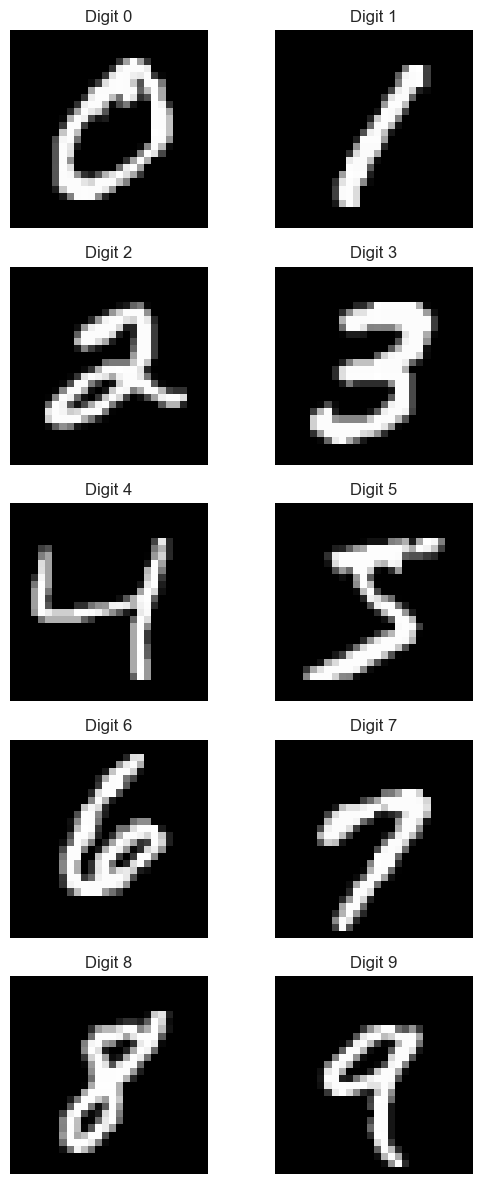

In [88]:
# D1: 5x2 sample grid (10 classes)
fig, axes = plt.subplots(5, 2, figsize=(6, 12))
for digit in range(10):
    idx = np.where(y_train_mn == digit)[0][0]
    ax = axes[digit // 2, digit % 2]
    ax.imshow(x_train[idx], cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [89]:
# D1: MLP baseline
mlp_baseline = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])
mlp_baseline.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

mlp_hist_mnist = mlp_baseline.fit(x_train_cnn, y_train_cat, validation_split=0.2, epochs=5, batch_size=64, verbose=0)
mlp_test_loss, mlp_test_acc = mlp_baseline.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"MLP baseline test accuracy: {mlp_test_acc:.4f}")

MLP baseline test accuracy: 0.9010


### D2 Lightweight CNN, augmentation, metrics, and confusion heatmap

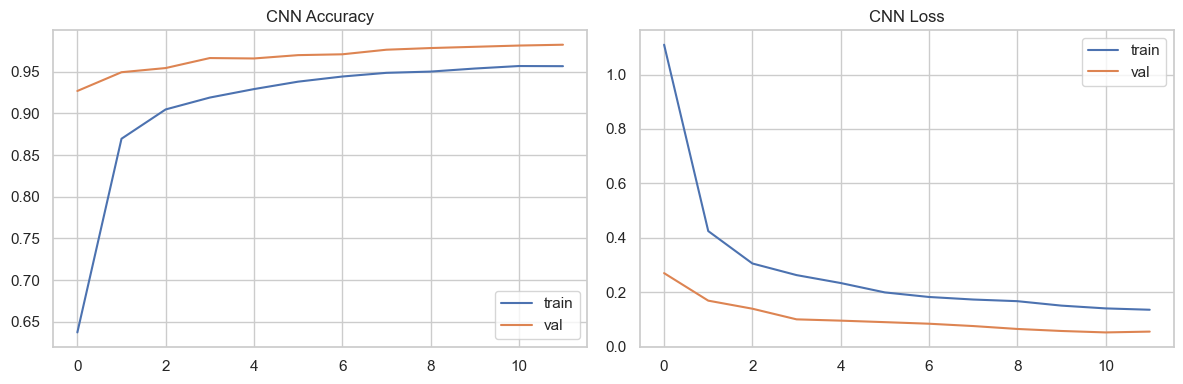

In [90]:
# D2: CNN model and augmentation
cnn = Sequential([
    Conv2D(16, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

cnn.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

datagen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1)
datagen.fit(x_train_cnn)

cnn_hist = cnn.fit(
    datagen.flow(x_train_cnn, y_train_cat, batch_size=64),
    validation_data=(x_test_cnn, y_test_cat),
    epochs=12,
    verbose=0,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_hist.history["accuracy"], label="train")
axes[0].plot(cnn_hist.history["val_accuracy"], label="val")
axes[0].set_title("CNN Accuracy")
axes[0].legend()

axes[1].plot(cnn_hist.history["loss"], label="train")
axes[1].plot(cnn_hist.history["val_loss"], label="val")
axes[1].set_title("CNN Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CNN test accuracy: 0.9825
CNN macro F1:      0.9823


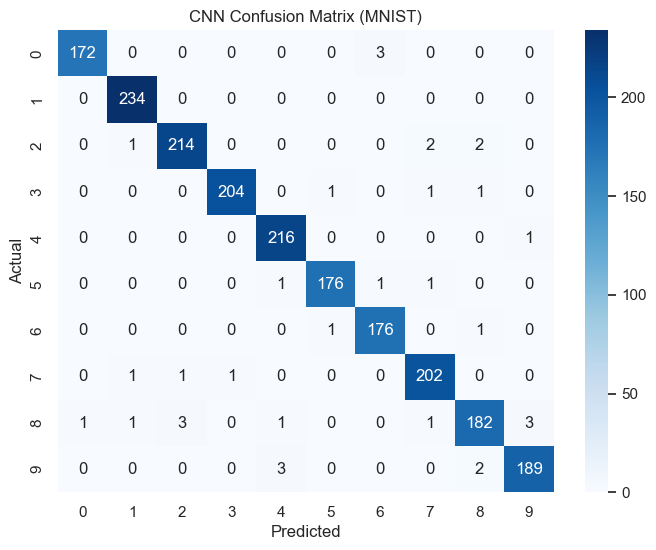

MLP baseline accuracy: 0.9010
CNN accuracy:          0.9825
Epoch when CNN surpasses MLP baseline: 1


In [91]:
# D2: CNN evaluation and confusion matrix
cnn_prob = cnn.predict(x_test_cnn)
cnn_pred = np.argmax(cnn_prob, axis=1)

cnn_acc = accuracy_score(y_test_mn, cnn_pred)
cnn_f1_macro = f1_score(y_test_mn, cnn_pred, average="macro")
print(f"CNN test accuracy: {cnn_acc:.4f}")
print(f"CNN macro F1:      {cnn_f1_macro:.4f}")

cm_mn = confusion_matrix(y_test_mn, cnn_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mn, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix (MNIST)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"MLP baseline accuracy: {mlp_test_acc:.4f}")
print(f"CNN accuracy:          {cnn_acc:.4f}")

first_better_epoch = next((i + 1 for i, val in enumerate(cnn_hist.history["val_accuracy"]) if val > mlp_test_acc), None)
print("Epoch when CNN surpasses MLP baseline:", first_better_epoch)

### D3 Visualize learned filters and feature maps

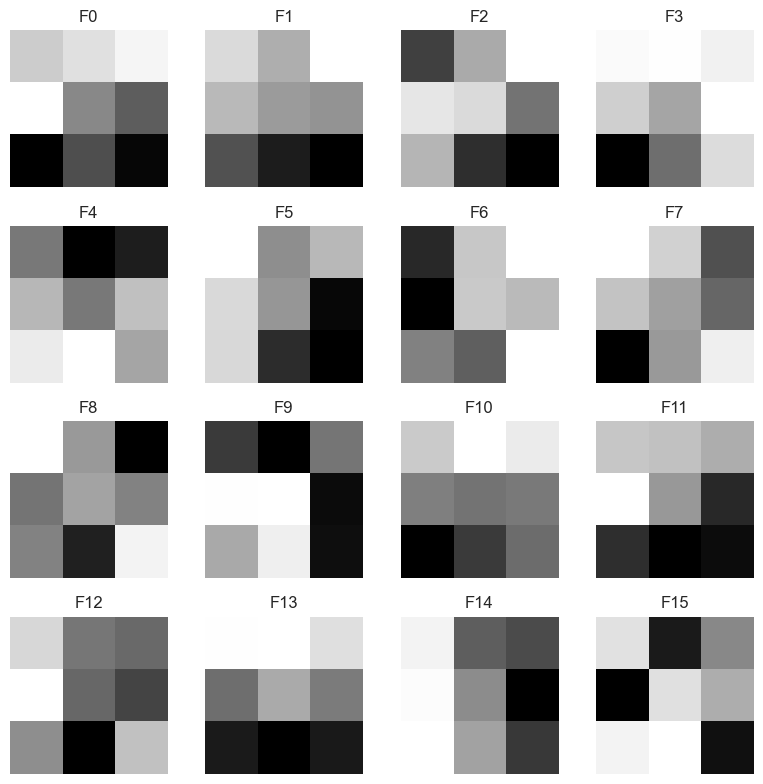

In [92]:
# D3: first conv filters (16 filters in 4x4)
filters, _ = cnn.layers[0].get_weights()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[:, :, 0, i], cmap="gray")
    ax.axis("off")
    ax.set_title(f"F{i}")
plt.tight_layout()
plt.show()

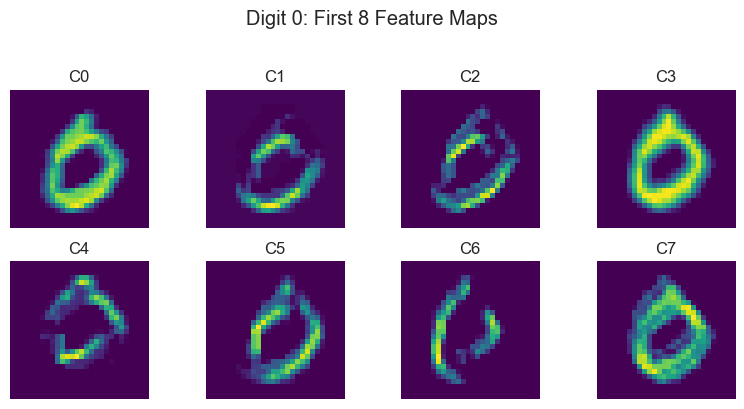

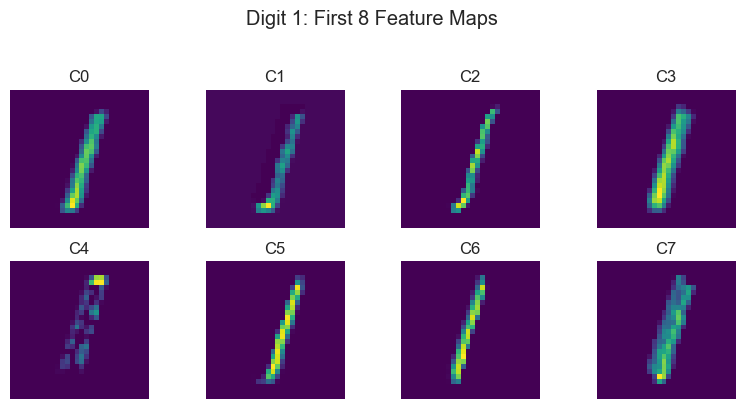

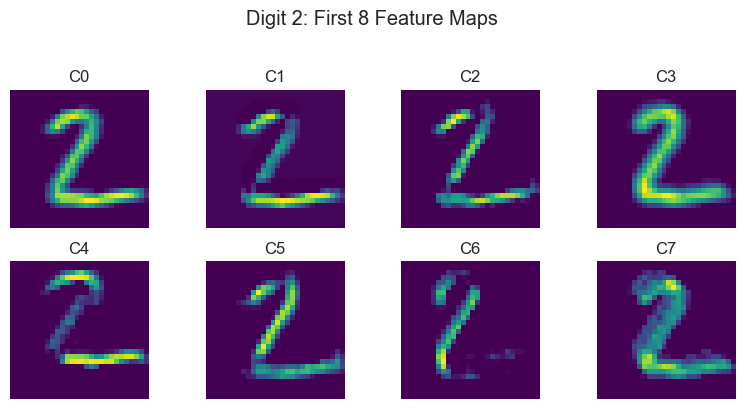

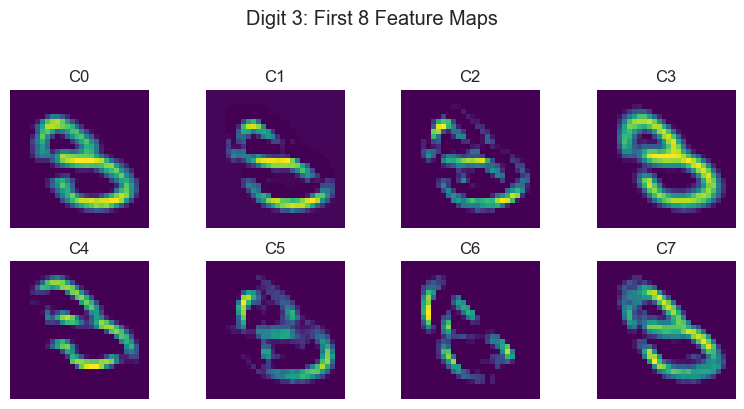

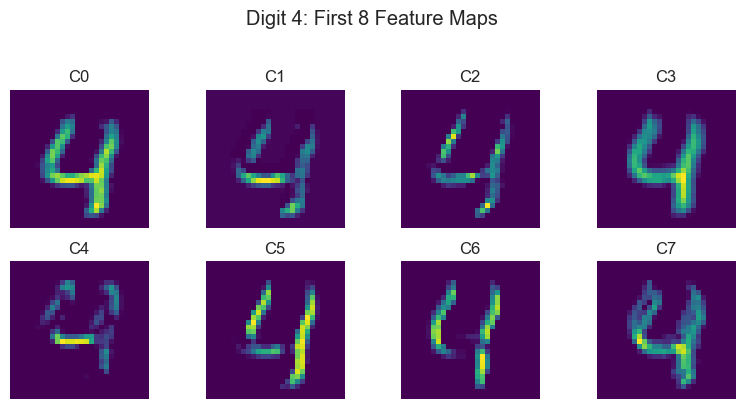

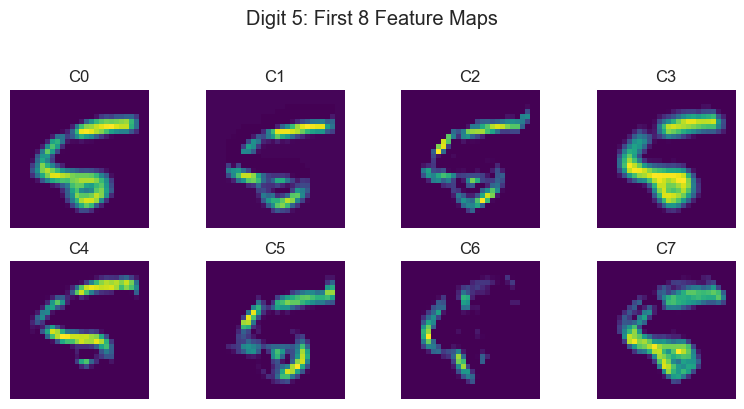

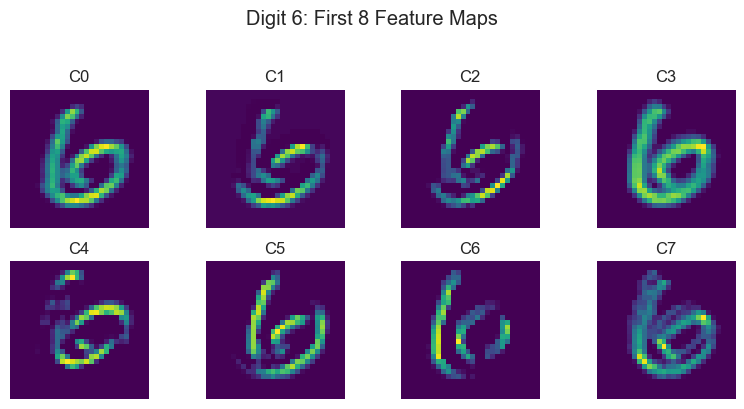

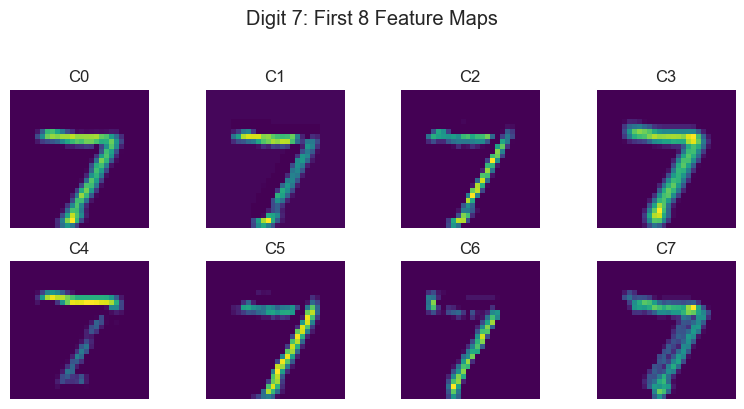

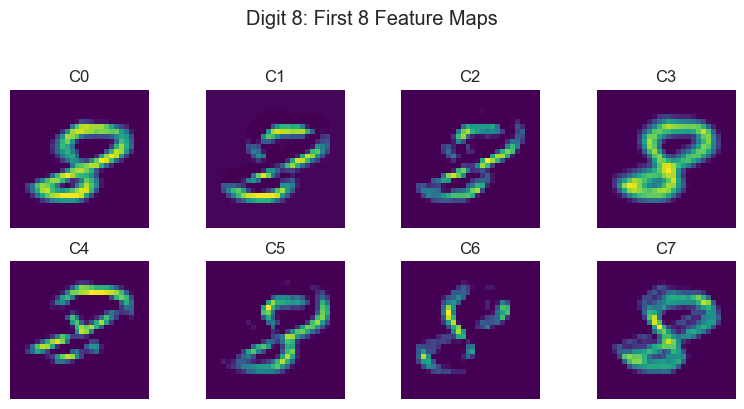

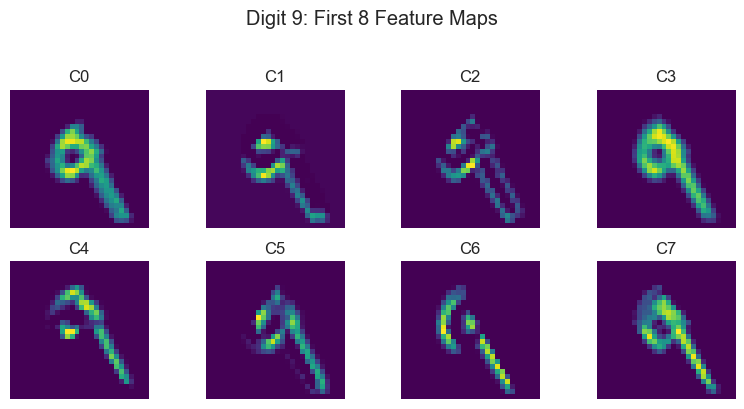

In [93]:
# D3: feature maps for one sample from each digit class
# Make sure the CNN has a defined input (cell run order can change)
if not getattr(cnn, "built", False):
    cnn.build((None, 28, 28, 1))

feature_model = Model(inputs=cnn.inputs, outputs=cnn.layers[0].output)

# Run one batched pass to avoid retracing warnings
indices = [int(np.where(y_test_mn == d)[0][0]) for d in range(10)]
batch = x_test_cnn[indices]
feature_maps = feature_model(batch, training=False).numpy()  # (10, 28, 28, 16)

for digit in range(10):
    fmap = feature_maps[digit]

    fig, axes = plt.subplots(2, 4, figsize=(8, 4))
    fig.suptitle(f"Digit {digit}: First 8 Feature Maps", y=1.02)
    for ch, ax in enumerate(axes.flat):
        ax.imshow(fmap[:, :, ch], cmap="viridis")
        ax.axis("off")
        ax.set_title(f"C{ch}")
    plt.tight_layout()
    plt.show()


## Part E: Local Front-End Dashboard Assets

### E1-E3 Train deployable heart model, save model and metadata

In [94]:
# Part E: save best practical model for app
# Here we use tuned Random Forest pipeline for strong performance + interpretability
rf_best.fit(X_train, y_train)
joblib.dump(rf_best, "heart_rf_pipeline.pkl")

# Save one real test sample for form prefill
sample_patient = X_test.iloc[0].to_dict()
joblib.dump(sample_patient, "sample_patient.pkl")

# Save top features for app explanation
top5_features = fi.head(5).to_dict(orient="records")
joblib.dump(top5_features, "top_features.pkl")

print("Saved: heart_rf_pipeline.pkl, sample_patient.pkl, top_features.pkl")

Saved: heart_rf_pipeline.pkl, sample_patient.pkl, top_features.pkl
